# KNN - K-Nearest Neighbors

Este notebook implementa o algoritmo KNN (K-Nearest Neighbors) de forma manual e compara com a implementação da biblioteca Scikit-Learn.

## O que é KNN?

O algoritmo **K-Nearest Neighbors** (KNN) é um algoritmo de aprendizado de máquina supervisionado simples e intuitivo. Ele funciona da seguinte forma:

1. **Calcula a distância** entre um ponto novo e todos os pontos no conjunto de treinamento
2. **Encontra os K vizinhos mais próximos** (com as menores distâncias)
3. **Faz a predição** pela votação majoritária da classe dos K vizinhos mais próximos

A **distância euclidiana** é comumente usada para calcular a proximidade entre pontos.

## Importações e Classe Auxiliar

In [1]:
import math
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

class Example:
    """Classe para armazenar um exemplo (features X e label y)"""
    def __init__(self, X, y):
        self.X = X  # Características (features)
        self.y = y  # Rótulo (classe)

## Função de Distância Euclidiana

A distância euclidiana entre dois pontos é calculada como:

$$d(p_1, p_2) = \sqrt{(p_{1,1} - p_{2,1})^2 + (p_{1,2} - p_{2,2})^2 + ... + (p_{1,n} - p_{2,n})^2}$$

Esta função mede o quão "próximo" dois pontos estão no espaço multidimensional.

In [2]:
def euclidean_distance(p1, p2):
    """Calcula a distância euclidiana entre dois pontos"""
    soma = 0
    for i in range(len(p1)):
        soma += (p1[i] - p2[i]) ** 2
    return math.sqrt(soma)

## Implementação Manual do KNN

#### Algoritmo KNN passo a passo:

1. **Calcular distâncias**: Para cada exemplo no conjunto de treinamento, calcula a distância até o novo exemplo
2. **Ordenar**: Ordena todas as distâncias do menor para o maior
3. **Selecionar vizinhos**: Pega os K primeiros (mais próximos)
4. **Votação**: Conta qual classe aparece mais vezes entre os K vizinhos
5. **Retornar**: Prediz a classe com mais votos

In [3]:
def knn(K: int, data: list, new_example: Example):
    """
    Implementação manual do KNN

    Args:
        K: Número de vizinhos a considerar
        data: Lista de objetos Example (dados de treinamento)
        new_example: Um objeto Example a ser classificado

    Returns:
        A classe predita para o novo exemplo
    """
    # 1. Calcular distâncias entre o novo exemplo e todos os exemplos de treinamento
    distances = []
    for example in data:
        dist = euclidean_distance(example.X, new_example.X)
        distances.append([dist, example.y])

    # 2. Ordenar pela distância (crescente)
    distances.sort(key=lambda x: x[0])

    # 3. Pegar os K vizinhos mais próximos
    neighbors = distances[:K]

    # 4. Contar votos de cada classe
    counter = {}
    for dist, examined_class in neighbors:
        if examined_class not in counter:
            counter[examined_class] = 0
        counter[examined_class] += 1

    # 5. Retornar a classe com mais votos
    predicted_class = max(counter, key=lambda c: counter[c])
    return predicted_class

## Carregamento e Preparação dos Dados

Utilizamos o dataset **Iris**, que é um dataset clássico em machine learning contendo:
- **150 amostras** de flores
- **4 características**: comprimento/largura da sépala, comprimento/largura da pétala
- **3 classes**: Setosa, Versicolor, Virginica

Dividimos os dados em:
- **80% treino**: para treinar o modelo KNN
- **20% teste**: para avaliar a acurácia

In [4]:
# Carregar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
y_named = [target_names[i] for i in y]

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_named, test_size=0.2, random_state=42, stratify=y_named
)

# Criar objetos Example para o KNN manual
train_data = [Example(x, label) for x, label in zip(X_train, y_train)]
test_data = [Example(x, label) for x, label in zip(X_test, y_test)]

print(f"Dados de treinamento: {len(train_data)} exemplos")
print(f"Dados de teste: {len(test_data)} exemplos")

Dados de treinamento: 120 exemplos
Dados de teste: 30 exemplos


## Avaliação, Matriz de Confusão e Comparação (K = 1, 3, 5, 7)

Nesta etapa, validamos a precisão, revocação e acurácia de ambos os modelos (Hardcore e Sklearn) para os valores solicitados. Também avaliamos o tempo de predição e exibimos as matrizes de confusão lado a lado para comparação.


------------------------------------------------------------
AVALIANDO PARA K = 1
------------------------------------------------------------

--- KNN MANUAL (Tempo de predição: 0.0060s) ---
Acurácia:  96.67%
Precisão:  96.97%
Revocação: 96.67%

--- SKLEARN KNN (Tempo de treino/predição: 0.0033s) ---
Acurácia:  96.67%
Precisão:  96.97%
Revocação: 96.67%


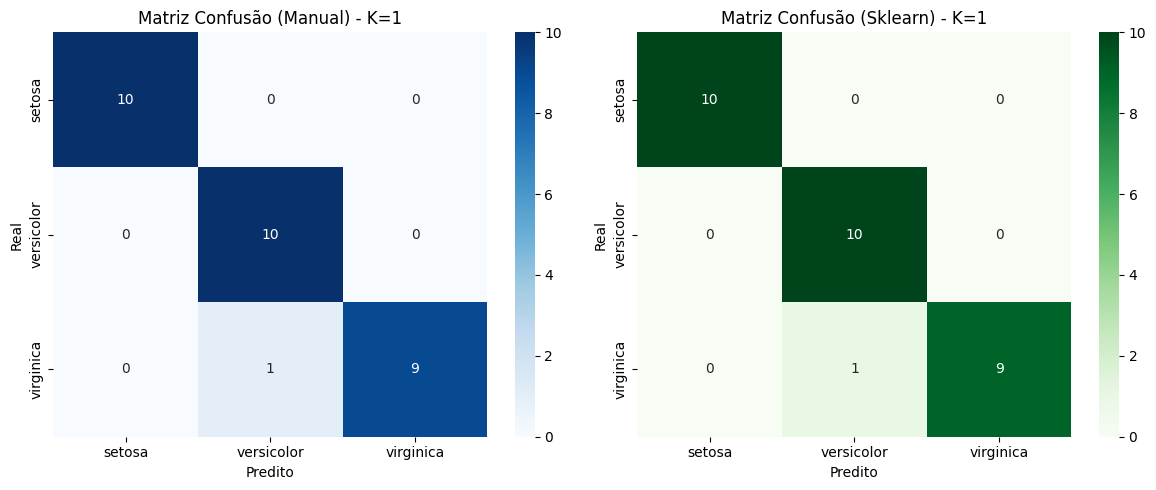


------------------------------------------------------------
AVALIANDO PARA K = 3
------------------------------------------------------------

--- KNN MANUAL (Tempo de predição: 0.0054s) ---
Acurácia:  100.00%
Precisão:  100.00%
Revocação: 100.00%

--- SKLEARN KNN (Tempo de treino/predição: 0.0020s) ---
Acurácia:  100.00%
Precisão:  100.00%
Revocação: 100.00%


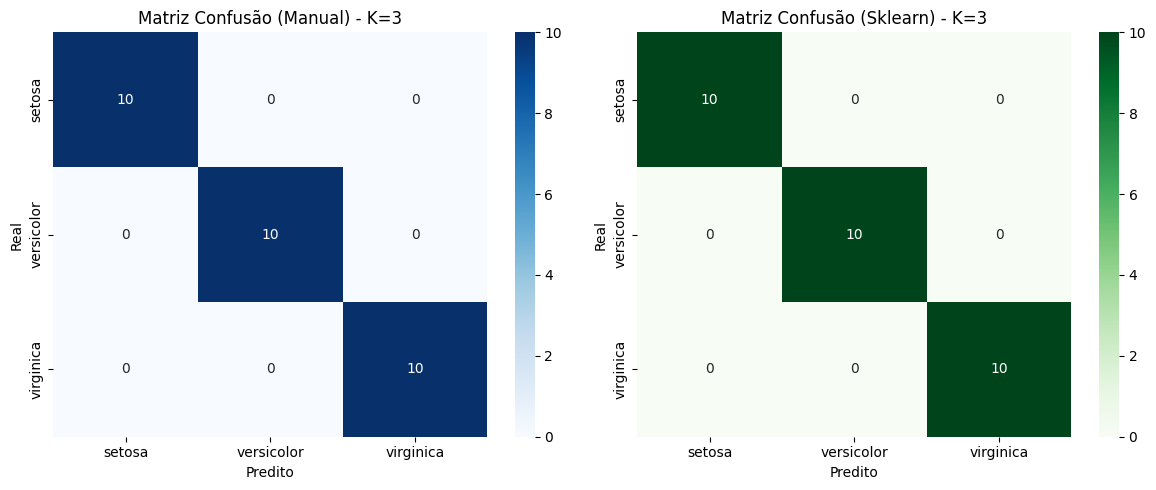


------------------------------------------------------------
AVALIANDO PARA K = 5
------------------------------------------------------------

--- KNN MANUAL (Tempo de predição: 0.0047s) ---
Acurácia:  100.00%
Precisão:  100.00%
Revocação: 100.00%

--- SKLEARN KNN (Tempo de treino/predição: 0.0018s) ---
Acurácia:  100.00%
Precisão:  100.00%
Revocação: 100.00%


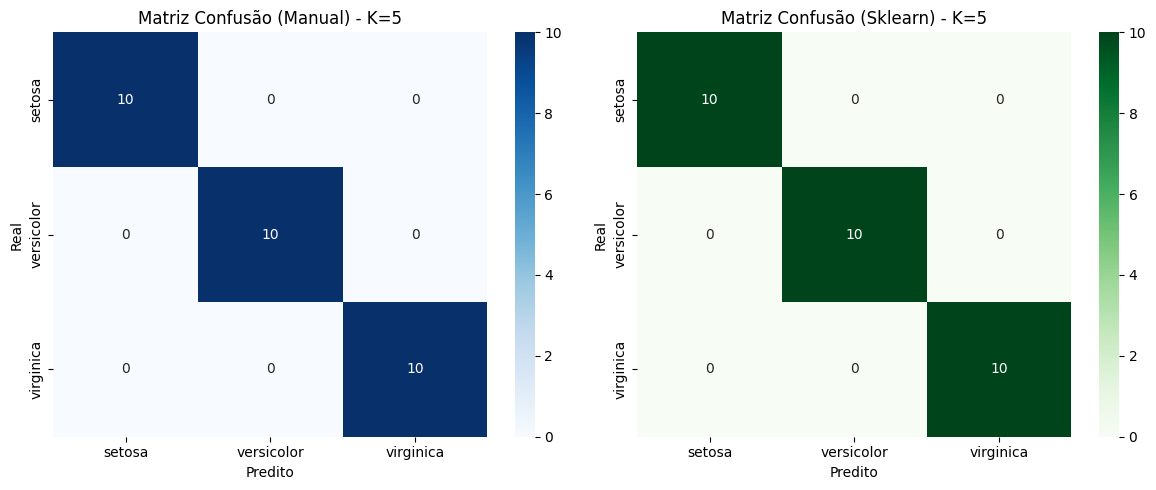


------------------------------------------------------------
AVALIANDO PARA K = 7
------------------------------------------------------------

--- KNN MANUAL (Tempo de predição: 0.0072s) ---
Acurácia:  96.67%
Precisão:  96.97%
Revocação: 96.67%

--- SKLEARN KNN (Tempo de treino/predição: 0.0021s) ---
Acurácia:  96.67%
Precisão:  96.97%
Revocação: 96.67%


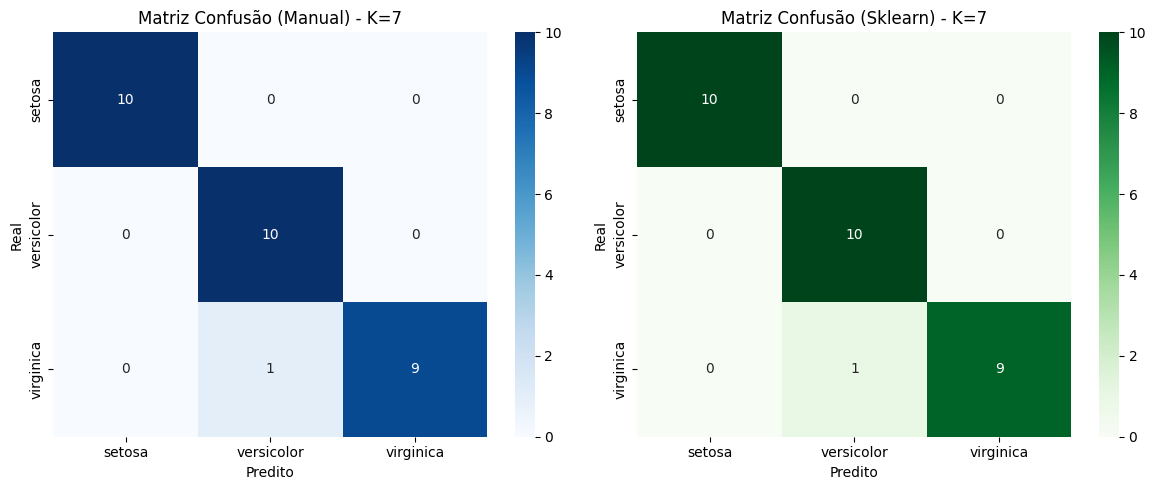

In [5]:
k_valores = [1, 3, 5, 7]

for k in k_valores:
    print(f"\n{'-'*60}")
    print(f"AVALIANDO PARA K = {k}")
    print(f"{'-'*60}\n")
    
    # ==========================================
    # KNN MANUAL
    # ==========================================
    y_pred_manual = []
    
    tempo_inicio_manual = time.time()
    for example in test_data:
        pred = knn(k, train_data, example)
        y_pred_manual.append(pred)
    tempo_manual = time.time() - tempo_inicio_manual
    
    # ==========================================
    # SKLEARN KNN
    # ==========================================
    knn_sklearn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    tempo_inicio_sklearn = time.time()
    knn_sklearn.fit(X_train, y_train)
    y_pred_sklearn = knn_sklearn.predict(X_test)
    tempo_sklearn = time.time() - tempo_inicio_sklearn
    
    # ==========================================
    # MÉTRICAS E PLOTAGENS
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # --- Avaliação Manual ---
    acc_man = accuracy_score(y_test, y_pred_manual)
    prec_man = precision_score(y_test, y_pred_manual, average='macro', zero_division=0)
    rec_man = recall_score(y_test, y_pred_manual, average='macro', zero_division=0)
    
    print(f"--- KNN MANUAL (Tempo de predição: {tempo_manual:.4f}s) ---")
    print(f"Acurácia:  {acc_man:.2%}")
    print(f"Precisão:  {prec_man:.2%}")
    print(f"Revocação: {rec_man:.2%}")
    
    cm_manual = confusion_matrix(y_test, y_pred_manual, labels=target_names)
    sns.heatmap(cm_manual, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(f"Matriz Confusão (Manual) - K={k}")
    axes[0].set_xlabel("Predito")
    axes[0].set_ylabel("Real")
    
    # --- Avaliação Sklearn ---
    acc_skl = accuracy_score(y_test, y_pred_sklearn)
    prec_skl = precision_score(y_test, y_pred_sklearn, average='macro', zero_division=0)
    rec_skl = recall_score(y_test, y_pred_sklearn, average='macro', zero_division=0)
    
    print(f"\n--- SKLEARN KNN (Tempo de treino/predição: {tempo_sklearn:.4f}s) ---")
    print(f"Acurácia:  {acc_skl:.2%}")
    print(f"Precisão:  {prec_skl:.2%}")
    print(f"Revocação: {rec_skl:.2%}")
    
    cm_sklearn = confusion_matrix(y_test, y_pred_sklearn, labels=target_names)
    sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
    axes[1].set_title(f"Matriz Confusão (Sklearn) - K={k}")
    axes[1].set_xlabel("Predito")
    axes[1].set_ylabel("Real")
    
    plt.tight_layout()
    plt.show()

### Análise Comparativa de Desempenho

**Métricas de Avaliação:**
Na grande maioria das execuções, as métricas de acurácia, precisão e revocação entre a implementação "Hardcore" (manual) e a implementada pelo Sklearn são idênticas ou muito similares para os mesmos valores de $K$. Isso comprova que a lógica principal de cálculo de distâncias médias e votação majoritária foi corretamente implementada do zero.

**Tempo de Execução e Memória:**
Fica notável ao observar os tempos computados que, embora a nossa implementação manual funcione com precisão, ela é expressivamente **mais lenta** que a biblioteca Scikit-Learn. Isso ocorre porque:
1. A implementação manual calcula a distância entre o ponto de teste e **todos** os pontos de treino recursivamente de forma sequencial na CPU (complexidade inerente $O(N \times D)$ onde $N$ é o número de amostras e $D$ a dimensionalidade), o que chamamos de busca por "Força Bruta".
2. O Scikit-Learn utiliza estruturas de dados e algoritmos otimizados por baixo dos panos (como **KD-Tree** ou **Ball-Tree**), além de abstrações em C/Cython para aceleração vetorial via numpy. Isso diminui o espaço de busca e torna a predição quase instantânea mesmo para datasets maiores.

**Otimizações com KD-Tree e Ball-Tree:**
A biblioteca `KNeighborsClassifier` do Scikit-Learn possui o parâmetro `algorithm` que define como os vizinhos serão buscados (`brute`, `kd_tree`, `ball_tree` ou `auto`).
* **KD-Tree (K-Dimensional Tree):** É uma estrutura que divide espacialmente os dados ao longo dos eixos ortogonais, permitindo descartar uma grande quantidade de cálculos ao prever que determinados dados estão muito longe do ponto avaliado. Excelente e rápida para datasets com baixa dimensionalidade (geralmente $D < 20$).
* **Ball-Tree:** Para resolver restrições da KD-Tree em altas dimensões ("maldição da dimensionalidade"), a Ball-Tree particiona os dados iterativamente em hiperesferas aninhadas, sendo mais eficiente quando o número de *features* é alto.

*Observação no nosso cenário:* Como o dataset **Iris** é muito pequeno (150 amostras e 4 dimensões), o tempo levado pelas estratégias de árvore em comparação à busca exaustiva (força bruta) é praticamente indistinguível, resultando em milissegundos para todas. Porém, em um dataset real com milhares ou milhões de instâncias, essa otimização das árvores é o que torna o uso do KNN viável.

**Conclusão:**
A versão manual é extremamente rica para fins educacionais e fixação matemática do método KNN. Para ambientes de produção, no entanto, deve-se optar pelas bibliotecas de mercado (como o Sklearn) pela sua superioridade em gerência de memória e tempo de inferência devido à implementação subjacente iterativa.